<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [2]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  40.0MB/s    in 3.7s    

2026-09-29 03:31:18 (40.7 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


### Step 2: Import necessary libraries and load the dataset


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data


In [4]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [5]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


                    JobSatPoints_6  JobSatPoints_7
Age                                               
18-24 years old               15.0            20.0
25-34 years old               20.0            15.0
35-44 years old               20.0            15.0
45-54 years old               20.0            15.0
55-64 years old               20.0            20.0
65 years or older             20.0            15.0
Prefer not to say             10.0             7.0
Under 18 years old             1.5             5.0

<Figure size 1200x800 with 0 Axes>

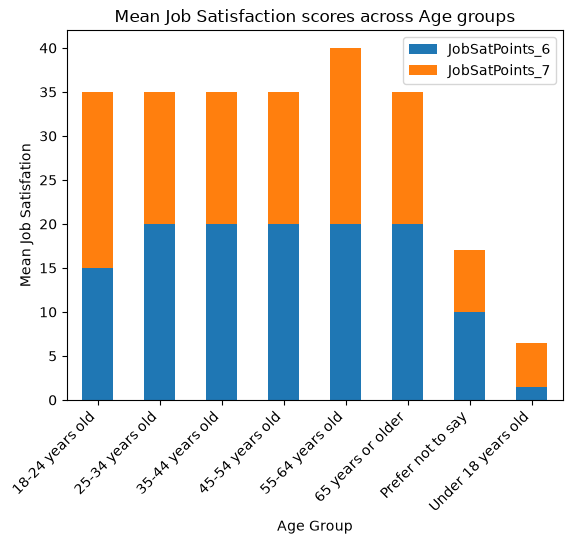

In [6]:
job_sat = df.groupby("Age")[["JobSatPoints_6", "JobSatPoints_7"]].median()
print(job_sat)

plt.figure(figsize = (12,8))
job_sat.plot(kind = "bar", stacked = True)
plt.title("Mean Job Satisfaction scores across Age groups")
plt.xlabel ("Age Group")
plt.ylabel("Mean Job Satisfation")
#plt.legend(["JobSatPoints_6"],["JobSatPoints_7"])
plt.xticks(rotation = 45, ha= "right")
plt.show()


##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


0        Employed, full-time
1        Employed, full-time
2        Employed, full-time
3         Student, full-time
4         Student, full-time
                ...         
65432    Employed, full-time
65433    Employed, full-time
65434    Employed, full-time
65435    Employed, full-time
65436     Student, full-time
Name: new_employment, Length: 77699, dtype: str

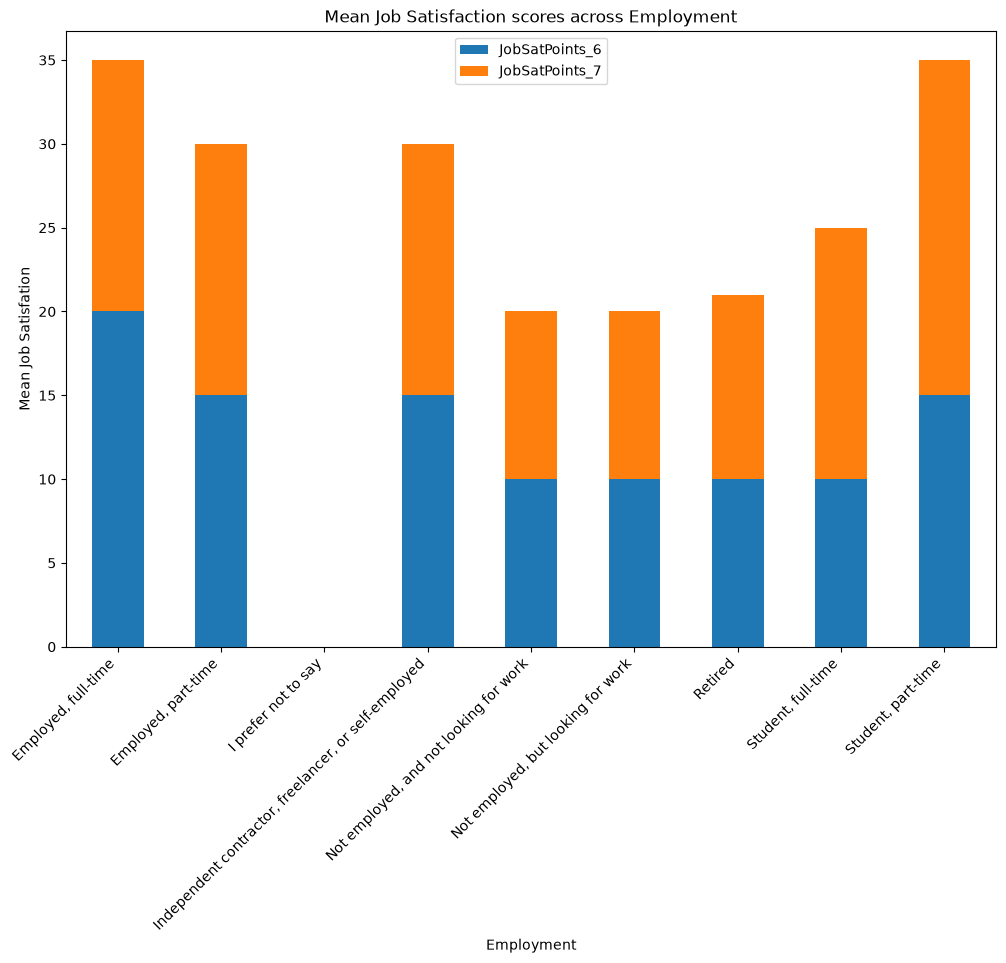

In [7]:
df["new_employment"] = df["Employment"].str.split(";")
df = df.explode("new_employment")
df["new_employment"] = df["new_employment"].str.strip()

print(df["new_employment"])
job_sat_em = df.groupby("new_employment")[["JobSatPoints_6", "JobSatPoints_7"]].median()
job_sat_em.dropna()

job_sat_em.plot(kind = "bar", stacked = True, figsize = (12,8))
plt.title("Mean Job Satisfaction scores across Employment")
plt.xlabel ("Employment")
plt.ylabel("Mean Job Satisfation")
#plt.legend(["JobSatPoints_6"],["JobSatPoints_7"])
plt.xticks(rotation = 45, ha= "right")
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


ConvertedCompYearly    58154.0
JobSatPoints_6            20.0
dtype: float64

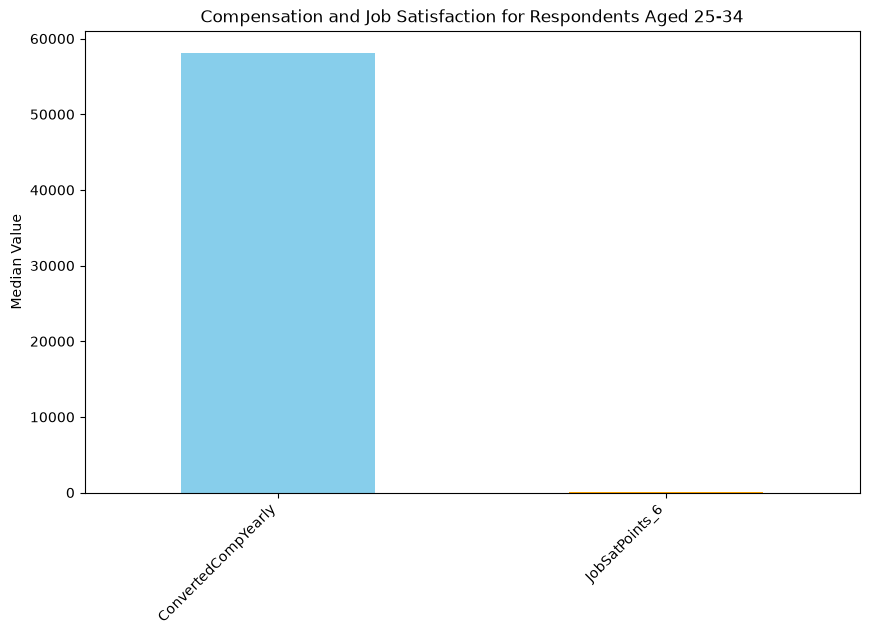

In [8]:
select_age = df[df["Age"] == "25-34 years old"]

age_data = select_age[
    ["ConvertedCompYearly", "JobSatPoints_6"]
].median()

print(age_data )
age_data.plot(
    kind="bar",
    figsize=(10, 6),
    color=["skyblue", "orange"]
)

plt.title("Compensation and Job Satisfaction for Respondents Aged 25-34")
plt.ylabel("Median Value")
plt.xticks(rotation = 45, ha = "right")
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


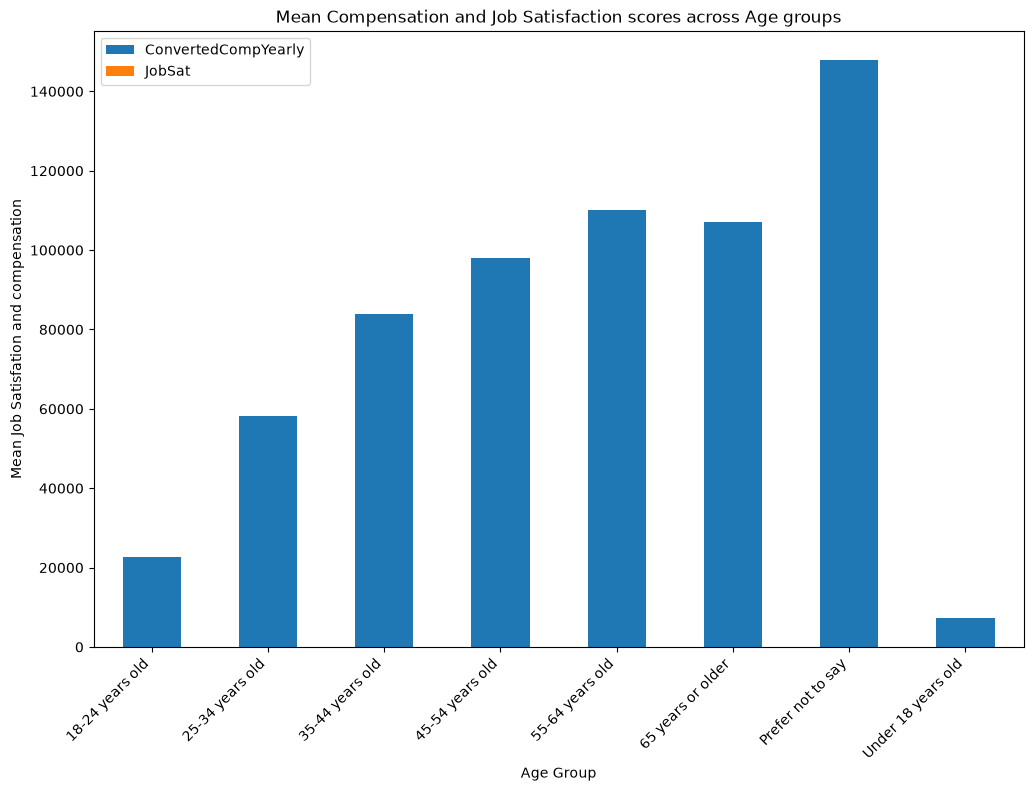

In [9]:
job_comp = df.groupby("Age")[["ConvertedCompYearly", "JobSat"]].median()

job_comp.plot(kind = "bar", stacked = True,figsize = (12,8))
plt.title("Mean Compensation and Job Satisfaction scores across Age groups")
plt.xlabel ("Age Group")
plt.ylabel("Mean Job Satisfation and compensation")
#plt.legend(["JobSatPoints_6"],["JobSatPoints_7"])
plt.xticks(rotation = 45, ha= "right")
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


In [12]:
df["DatabaseWantToWorkWith"] = df["DatabaseWantToWorkWith"].astype("string")

df["Databases"] = df["DatabaseWantToWorkWith"].str.split(";")
df = df.explode("Databases")
df["Databases"] = df["Databases"].str.strip()
db_want = df["Databases"].value_counts().head()

     Databases                 Age  Count
0      MongoDB     18-24 years old   4225
1      MongoDB     25-34 years old   5260
2      MongoDB     35-44 years old   2526
3      MongoDB     45-54 years old    919
4      MongoDB     55-64 years old    255
5      MongoDB   65 years or older     55
6      MongoDB   Prefer not to say     29
7      MongoDB  Under 18 years old    513
8        MySQL     18-24 years old   4303
9        MySQL     25-34 years old   5445
10       MySQL     35-44 years old   2993
11       MySQL     45-54 years old   1320
12       MySQL     55-64 years old    525
13       MySQL   65 years or older    168
14       MySQL   Prefer not to say     45
15       MySQL  Under 18 years old    569
16  PostgreSQL     18-24 years old   7125
17  PostgreSQL     25-34 years old  11214
18  PostgreSQL     35-44 years old   6648
19  PostgreSQL     45-54 years old   2507
20  PostgreSQL     55-64 years old    792
21  PostgreSQL   65 years or older    124
22  PostgreSQL   Prefer not to say

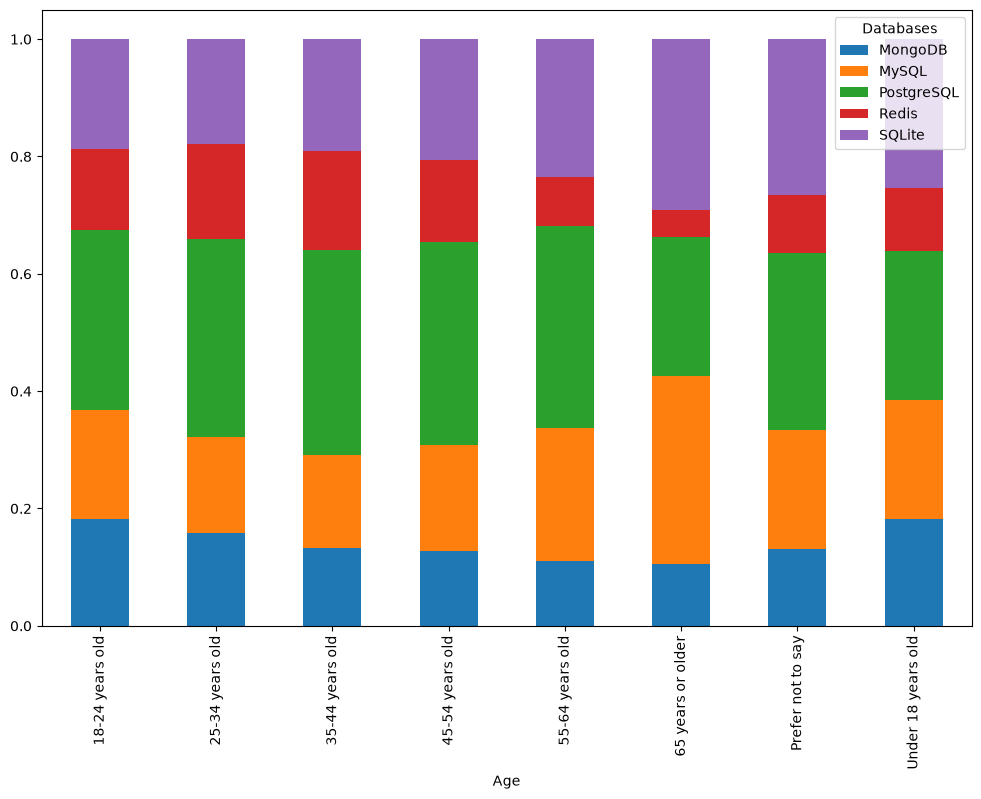

In [13]:
new_db = df[df["Databases"].isin(db_want.index)]
new_db = new_db.dropna(subset = ["Databases", "Age"])
new_db_group = new_db.groupby(["Databases","Age"]).size().reset_index(name = "Count")
print(new_db_group)
new_db_group["proportion"] = (new_db_group["Count"]/new_db_group.groupby("Age")["Count"].transform("sum"))
print(new_db_group)

db_pivot = new_db_group.pivot(index = "Age", columns = "Databases", values = "proportion")

db_pivot.plot(kind = "bar", stacked = True, figsize= (12,8))
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


          db_employment  JobSat  respondent_counts
0   Employed, full-time     0.0                895
1   Employed, full-time     1.0                970
2   Employed, full-time     2.0               2180
3   Employed, full-time     3.0               3148
4   Employed, full-time     4.0               3212
..                  ...     ...                ...
79   Student, part-time     6.0                968
80   Student, part-time     7.0               1115
81   Student, part-time     8.0               1767
82   Student, part-time     9.0                711
83   Student, part-time    10.0                628

[84 rows x 3 columns]

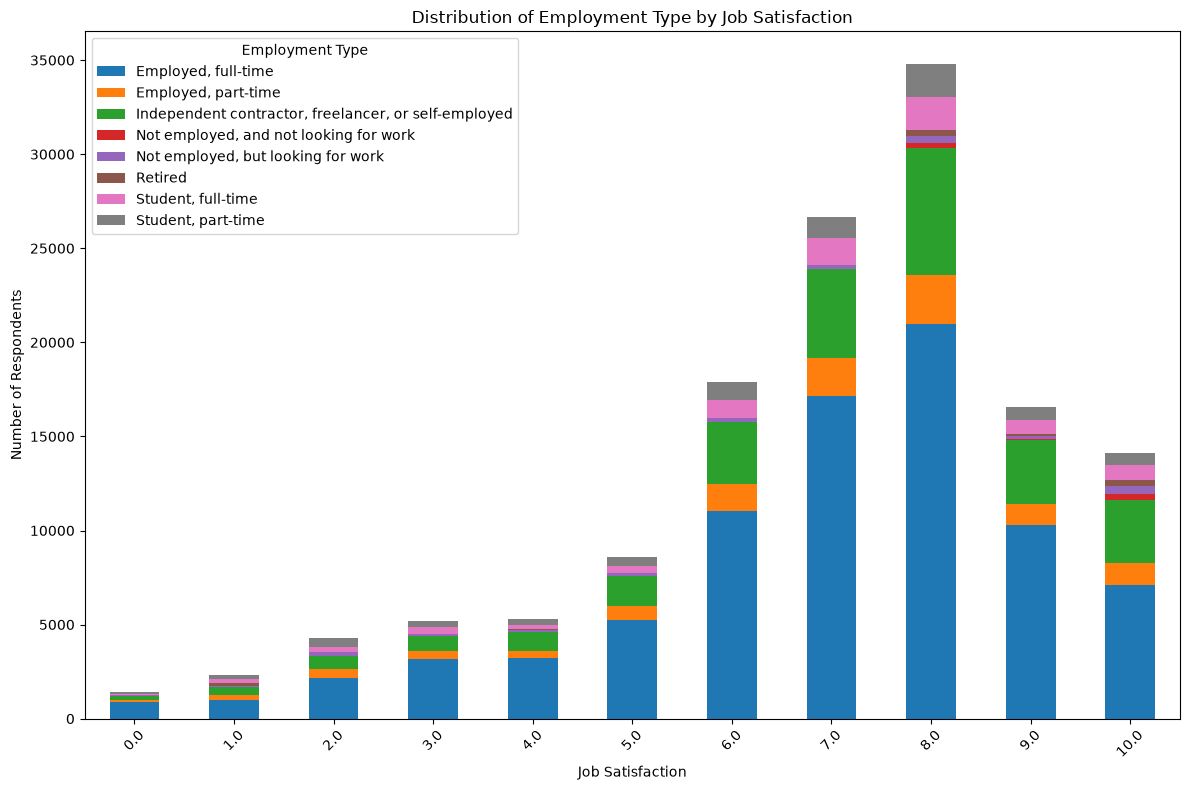

In [14]:
df["db_employment"] = df["Employment"].str.split(";")
df = df.explode("db_employment")
df["db_employment"] = df["db_employment"].str.strip()
new_employ_df = df.dropna(subset = ["db_employment","JobSat"])

group_employ = new_employ_df.groupby(["db_employment","JobSat"]).size().reset_index(name= "respondent_counts")
print(group_employ)

group_employ_pivot = group_employ.pivot(index= "JobSat", columns = "db_employment", values = "respondent_counts")

group_employ_pivot.plot(kind="bar", stacked = True, figsize= (12,8))
plt.title("Distribution of Employment Type by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Respondents")
plt.legend(title="Employment Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


    admired_language                 Age  Counts
0                Ada     18-24 years old      55
1                Ada     25-34 years old      97
2                Ada     35-44 years old      73
3                Ada     45-54 years old      43
4                Ada     55-64 years old      24
..               ...                 ...     ...
384              Zig     45-54 years old      38
385              Zig     55-64 years old      24
386              Zig   65 years or older       4
387              Zig   Prefer not to say       5
388              Zig  Under 18 years old      77

[389 rows x 3 columns]

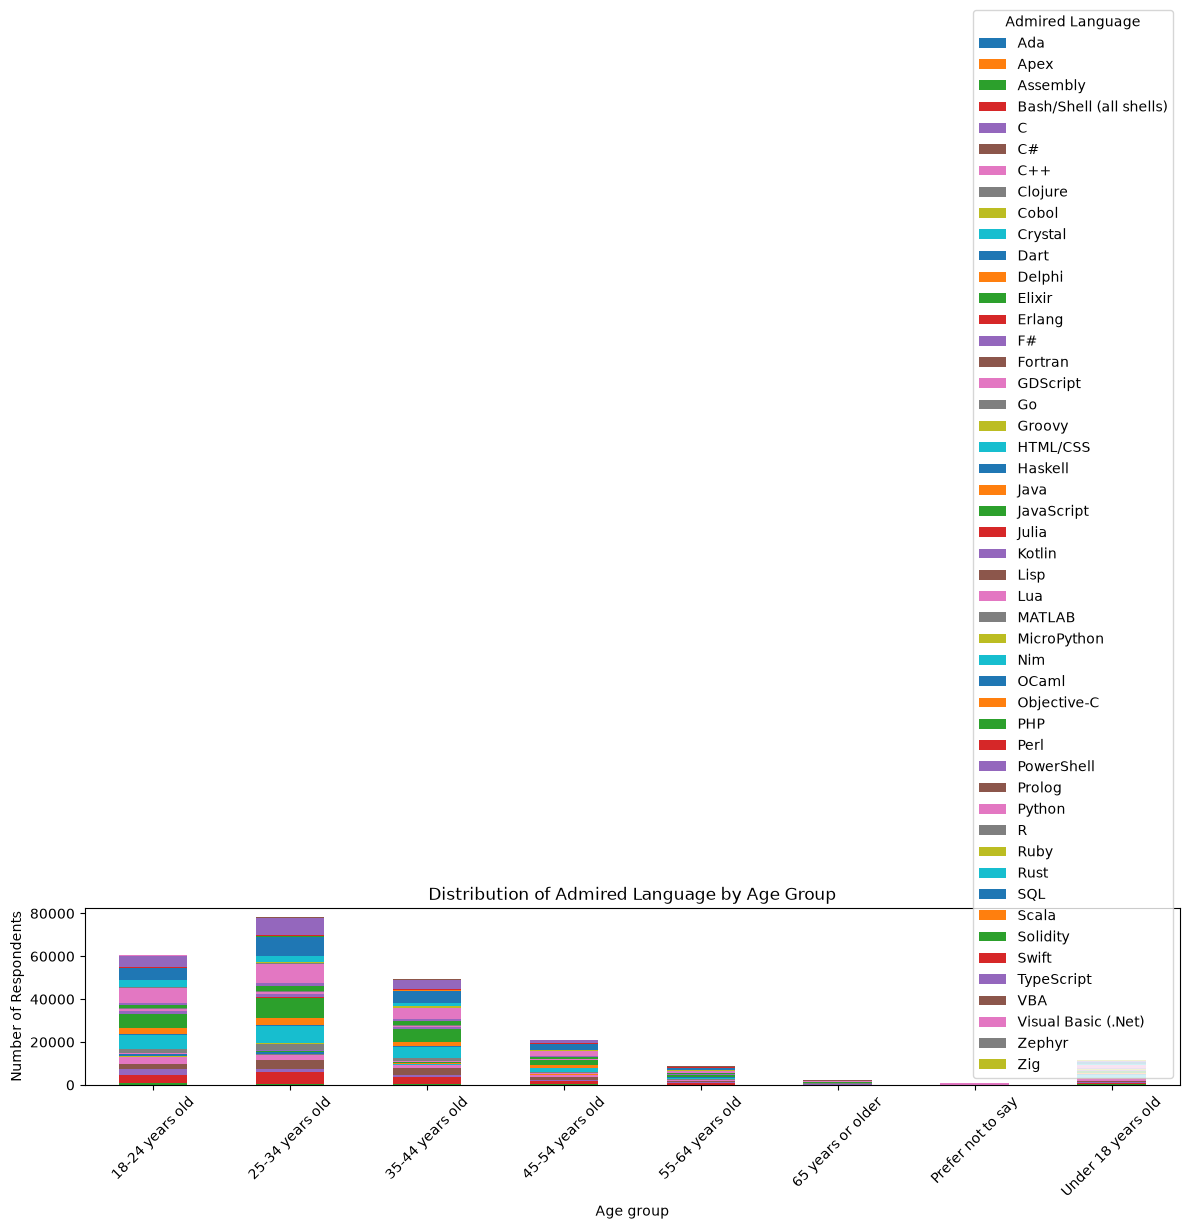

In [10]:
df["admired_language"] = df["LanguageAdmired"].str.split(";")
df = df.explode("admired_language")
df["admired_language"] = df["admired_language"].str.strip()
new_admired_lang = df.dropna(subset = ["admired_language","Age"])

group_admired_lang = new_admired_lang.groupby(["admired_language","Age"]).size().reset_index(name= "Counts")
print(group_admired_lang)

admired_pivot = group_admired_lang.pivot(index= "Age", columns = "admired_language", values = "Counts")

admired_pivot.plot(kind="bar", stacked = True, figsize= (12,8))
plt.title("Distribution of Admired Language by Age Group")
plt.xlabel("Age group")
plt.ylabel("Number of Respondents")
plt.legend(title= "Admired Language")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


/tmp/ipykernel_403/1318835154.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

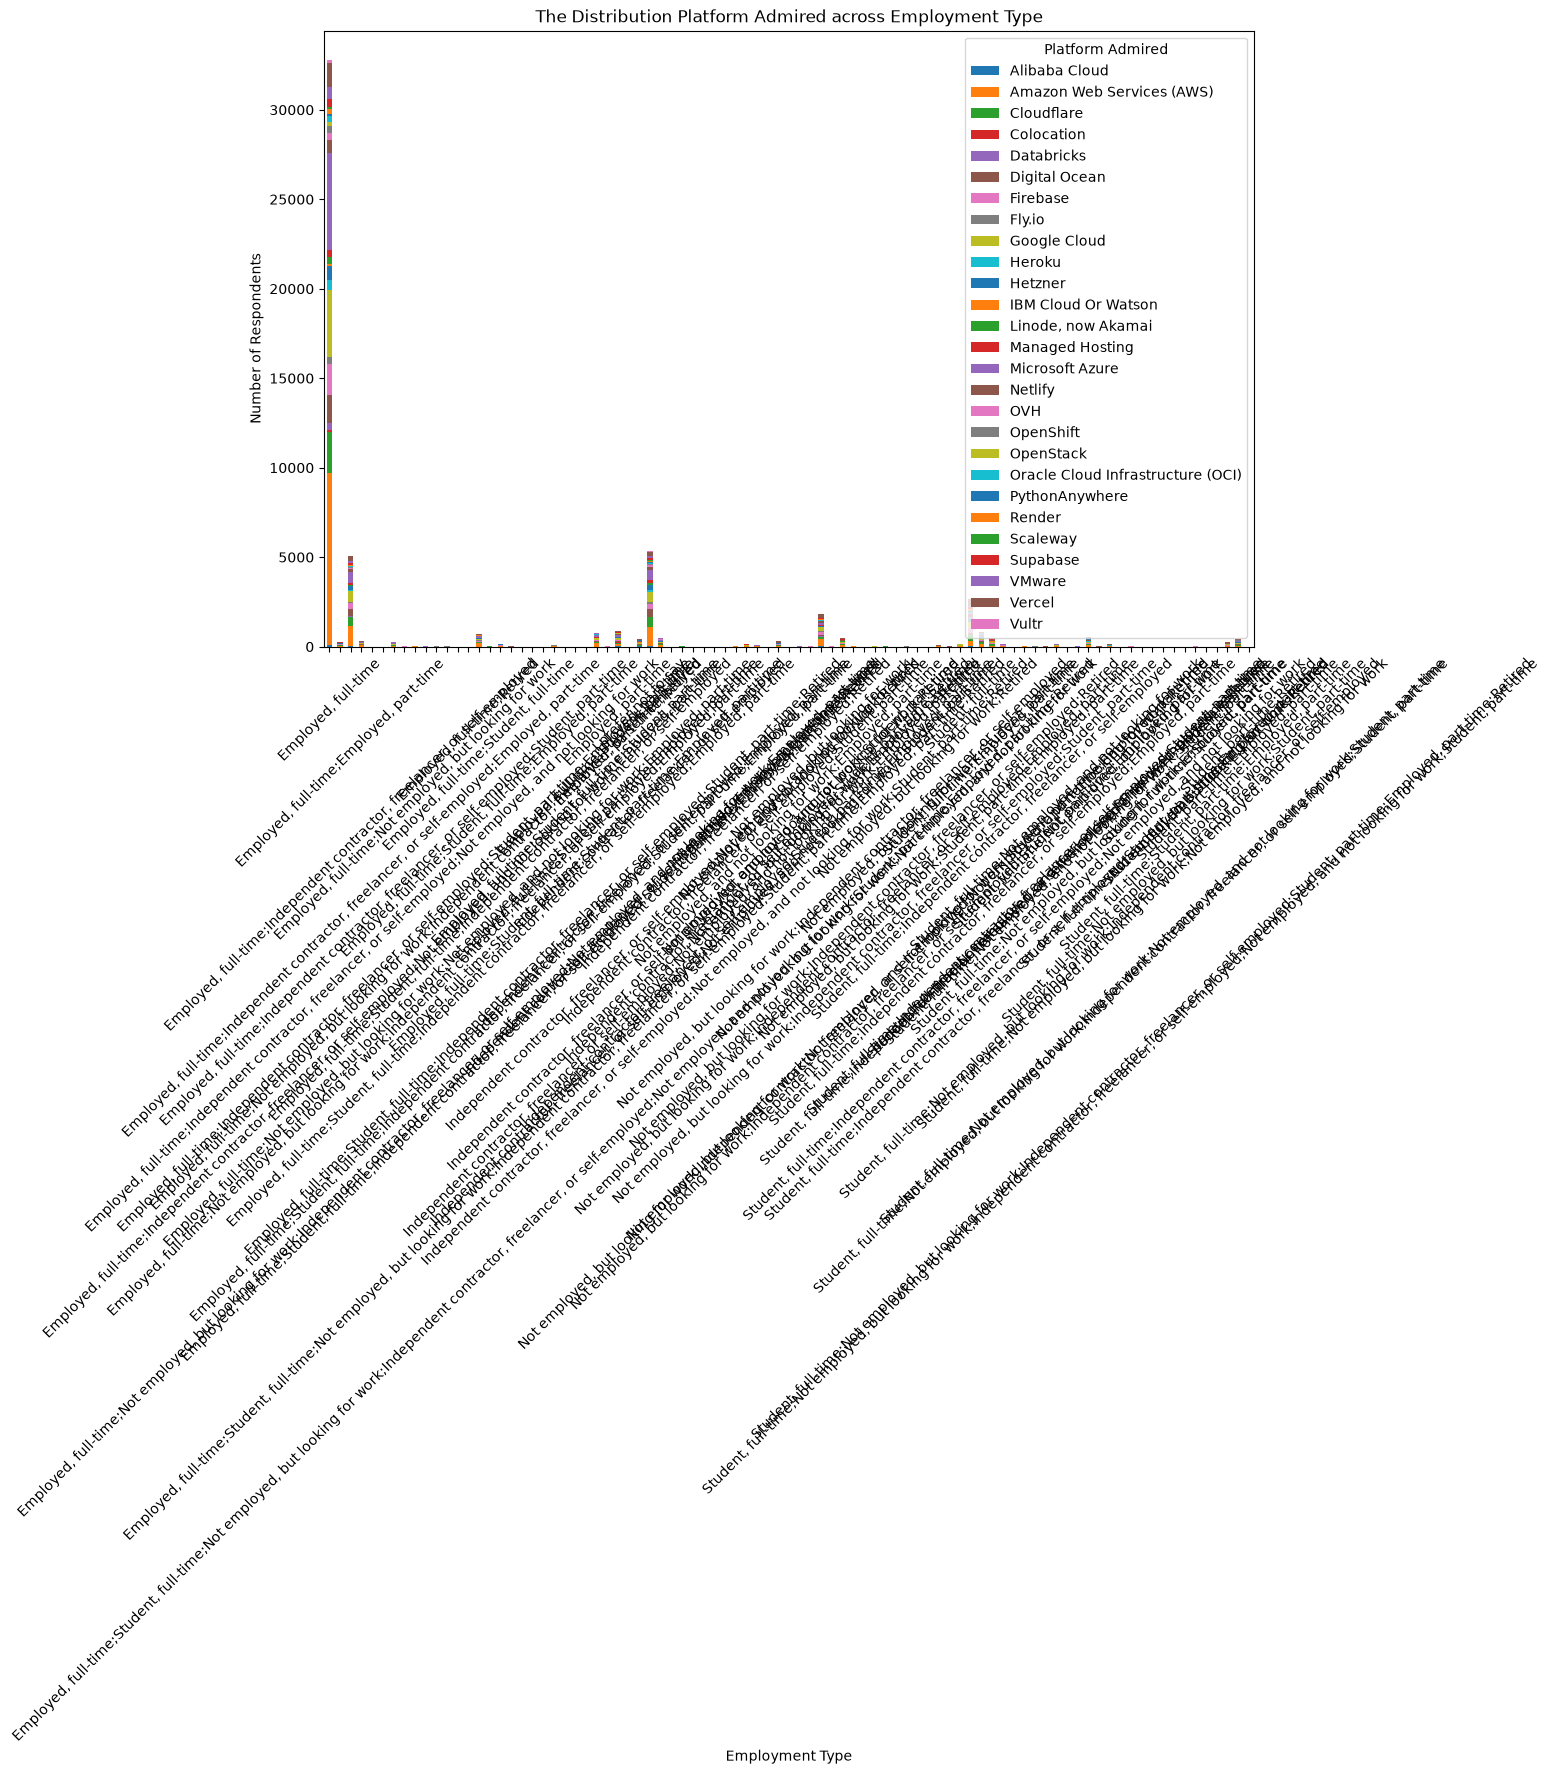

In [6]:
df["plat_admired"] = df["PlatformAdmired"].str.split(";")
df = df.explode("plat_admired")
df["plat_admired"] = df["plat_admired"].str.strip()
new_plat_admired = df.dropna(subset = ["plat_admired","Employment"])

group_plat_admired  = new_plat_admired.groupby(["plat_admired","Employment"]).size().reset_index(name= "Counts")

plat_dmired_pivot = group_plat_admired.pivot(index= "Employment", columns = "plat_admired", values = "Counts")

plat_dmired_pivot.plot(kind="bar", stacked = True, figsize= (12,8))
plt.title("The Distribution Platform Admired across Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Number of Respondents")
plt.legend(title= "Platform Admired")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
